In [1]:
# !pip install librosa matplotlib numpy scipy


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
import os
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from IPython.display import Audio, display


In [5]:
DATA_DIR = Path('/content/drive/MyDrive/BirdNET_Singapore/data/augmented')

wav_files = sorted(DATA_DIR.rglob('*.wav'))
print(f"Found {len(wav_files)} .wav files:\n")
for i, f in enumerate(wav_files):
    print(f"  [{i:02d}] {f.relative_to(DATA_DIR)}")


Found 3048 .wav files:

  [00] Asian_Glossy_Starling_XC1031839_loud.wav
  [01] Asian_Glossy_Starling_XC1031839_noisy.wav
  [02] Asian_Glossy_Starling_XC1031839_pitch_down.wav
  [03] Asian_Glossy_Starling_XC1031839_pitch_up.wav
  [04] Asian_Glossy_Starling_XC1031839_quiet.wav
  [05] Asian_Glossy_Starling_XC1031839_timeshift.wav
  [06] Asian_Glossy_Starling_XC1031841_loud.wav
  [07] Asian_Glossy_Starling_XC1031841_noisy.wav
  [08] Asian_Glossy_Starling_XC1031841_pitch_down.wav
  [09] Asian_Glossy_Starling_XC1031841_pitch_up.wav
  [10] Asian_Glossy_Starling_XC1031841_quiet.wav
  [11] Asian_Glossy_Starling_XC1031841_timeshift.wav
  [12] Asian_Glossy_Starling_XC1032794_loud.wav
  [13] Asian_Glossy_Starling_XC1032794_noisy.wav
  [14] Asian_Glossy_Starling_XC1032794_pitch_down.wav
  [15] Asian_Glossy_Starling_XC1032794_pitch_up.wav
  [16] Asian_Glossy_Starling_XC1032794_quiet.wav
  [17] Asian_Glossy_Starling_XC1032794_timeshift.wav
  [18] Asian_Glossy_Starling_XC578355_loud.wav
  [19] Asian_G

In [6]:
# ── Cell 5: Helper — load & inspect a single file ───────────
def inspect_audio(path):
    """Print basic properties of a .wav file."""
    y, sr = librosa.load(path, sr=None)  # sr=None preserves original sample rate
    duration = librosa.get_duration(y=y, sr=sr)
    print(f"File      : {Path(path).name}")
    print(f"Sample rate: {sr} Hz")
    print(f"Duration  : {duration:.2f} s  ({len(y)} samples)")
    print(f"RMS energy: {np.sqrt(np.mean(y**2)):.4f}")
    return y, sr

In [7]:
# ── Cell 6: Plot full spectrogram suite for one file ────────
def plot_spectrogram_suite(path, n_mels=128, n_mfcc=13):
    y, sr = librosa.load(path, sr=None)
    name = Path(path).name

    # Compute representations
    S      = np.abs(librosa.stft(y))
    S_db   = librosa.amplitude_to_db(S, ref=np.max)
    S_mel  = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
    S_mel_db = librosa.power_to_db(S_mel, ref=np.max)
    mfcc   = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    onset_env = librosa.onset.onset_strength(y=y, sr=sr)
    onsets    = librosa.onset.onset_detect(y=y, sr=sr, units='time')

    fig = plt.figure(figsize=(16, 14))
    fig.suptitle(f"Spectrogram Suite — {name}", fontsize=14, fontweight='bold')
    gs = gridspec.GridSpec(4, 2, figure=fig, hspace=0.5, wspace=0.35)

    # 1. Waveform
    ax0 = fig.add_subplot(gs[0, :])
    librosa.display.waveshow(y, sr=sr, ax=ax0, color='steelblue', alpha=0.8)
    for t in onsets:
        ax0.axvline(t, color='tomato', alpha=0.6, linewidth=0.8)
    ax0.set_title('Waveform  (red lines = detected onsets)')
    ax0.set_xlabel('Time (s)')

    # 2. STFT spectrogram
    ax1 = fig.add_subplot(gs[1, 0])
    img = librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='hz', ax=ax1, cmap='magma')
    fig.colorbar(img, ax=ax1, format='%+2.0f dB')
    ax1.set_title('STFT Spectrogram')

    # 3. Mel spectrogram
    ax2 = fig.add_subplot(gs[1, 1])
    img2 = librosa.display.specshow(S_mel_db, sr=sr, x_axis='time', y_axis='mel', ax=ax2, cmap='magma')
    fig.colorbar(img2, ax=ax2, format='%+2.0f dB')
    ax2.set_title(f'Mel Spectrogram  (n_mels={n_mels})')

    # 4. MFCCs
    ax3 = fig.add_subplot(gs[2, 0])
    img3 = librosa.display.specshow(mfcc, sr=sr, x_axis='time', ax=ax3, cmap='coolwarm')
    fig.colorbar(img3, ax=ax3)
    ax3.set_title(f'MFCCs  (n={n_mfcc})')
    ax3.set_ylabel('MFCC coefficient')

    # 5. Chromagram
    ax4 = fig.add_subplot(gs[2, 1])
    img4 = librosa.display.specshow(chroma, sr=sr, x_axis='time', y_axis='chroma', ax=ax4, cmap='YlOrRd')
    fig.colorbar(img4, ax=ax4)
    ax4.set_title('Chromagram')

    # 6. Onset strength
    ax5 = fig.add_subplot(gs[3, :])
    times = librosa.times_like(onset_env, sr=sr)
    ax5.plot(times, onset_env, color='darkorange', linewidth=1.2)
    for t in onsets:
        ax5.axvline(t, color='tomato', alpha=0.5, linewidth=0.8)
    ax5.set_title('Onset Strength Envelope')
    ax5.set_xlabel('Time (s)')
    ax5.set_ylabel('Strength')

    plt.savefig(f"{Path(path).stem}_suite.png", dpi=150, bbox_inches='tight')
    plt.show()
    display(Audio(y, rate=sr))  # playback widget
    return y, sr

In [8]:
names = [
    'Asian_Koel_XC1058398_loud.wav',
    'Asian_Koel_XC1058398_noisy.wav',
    'Asian_Koel_XC1058398_pitch_down.wav',
    'Asian_Koel_XC1058398_pitch_up.wav',
    'Asian_Koel_XC1058398_quiet.wav',
    'Asian_Koel_XC1058398_timeshift.wav',
]
selected_files = [f for f in wav_files if f.name in names]


In [11]:
def analyse_all(files, n_mels=128, n_mfcc=13):
    for path in files:
        print(f"\n{'='*60}")
        print(f"FILE: {path.name}")
        print('='*60)
        inspect_audio(path)
        plot_spectrogram_suite(path, n_mels=n_mels, n_mfcc=n_mfcc)

analyse_all(selected_files)


Output hidden; open in https://colab.research.google.com to view.

In [14]:
# ── Save all spectrogram images to Drive ────────────────────
SAVE_DIR = DATA_DIR / 'spectrogram_outputs'
SAVE_DIR.mkdir(exist_ok=True)

for path in selected_files:
    y, sr = librosa.load(path, sr=None)
    name  = Path(path).stem
    tag   = name.replace('Asian_Koel_XC1058398_', '').upper()

    S_db     = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
    S_mel_db = librosa.power_to_db(librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128), ref=np.max)
    mfcc     = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    chroma   = librosa.feature.chroma_stft(y=y, sr=sr)
    onset_env = librosa.onset.onset_strength(y=y, sr=sr)
    onsets    = librosa.onset.onset_detect(y=y, sr=sr, units='time')
    times     = librosa.times_like(onset_env, sr=sr)

    fig = plt.figure(figsize=(16, 14))
    fig.suptitle(f"Asian Koel XC1058398 — {tag}", fontsize=15, fontweight='bold', y=0.98)
    gs = gridspec.GridSpec(4, 2, figure=fig, hspace=0.55, wspace=0.35)

    ax0 = fig.add_subplot(gs[0, :])
    librosa.display.waveshow(y, sr=sr, ax=ax0, color='steelblue', alpha=0.8)
    for t in onsets:
        ax0.axvline(t, color='tomato', alpha=0.6, linewidth=0.8)
    ax0.set_title('Waveform  (red = detected onsets)')

    ax1 = fig.add_subplot(gs[1, 0])
    img1 = librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='hz', ax=ax1, cmap='magma')
    fig.colorbar(img1, ax=ax1, format='%+2.0f dB')
    ax1.set_title('STFT Spectrogram')

    ax2 = fig.add_subplot(gs[1, 1])
    img2 = librosa.display.specshow(S_mel_db, sr=sr, x_axis='time', y_axis='mel', ax=ax2, cmap='magma')
    fig.colorbar(img2, ax=ax2, format='%+2.0f dB')
    ax2.set_title('Mel Spectrogram')

    ax3 = fig.add_subplot(gs[2, 0])
    img3 = librosa.display.specshow(mfcc, sr=sr, x_axis='time', ax=ax3, cmap='coolwarm')
    fig.colorbar(img3, ax=ax3)
    ax3.set_title('MFCCs')

    ax4 = fig.add_subplot(gs[2, 1])
    img4 = librosa.display.specshow(chroma, sr=sr, x_axis='time', y_axis='chroma', ax=ax4, cmap='YlOrRd')
    fig.colorbar(img4, ax=ax4)
    ax4.set_title('Chromagram')

    ax5 = fig.add_subplot(gs[3, :])
    ax5.plot(times, onset_env, color='darkorange', linewidth=1.2)
    for t in onsets:
        ax5.axvline(t, color='tomato', alpha=0.5, linewidth=0.8)
    ax5.set_title('Onset Strength Envelope')
    ax5.set_xlabel('Time (s)')

    save_path = SAVE_DIR / f"{name}_suite.png"
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.close(fig)  # don't render in notebook, just save
    print(f"  Saved → {save_path.relative_to(DATA_DIR)}")

print(f"\nDone. All images saved to: {SAVE_DIR}")

  Saved → spectrogram_outputs/Asian_Koel_XC1058398_loud_suite.png
  Saved → spectrogram_outputs/Asian_Koel_XC1058398_noisy_suite.png
  Saved → spectrogram_outputs/Asian_Koel_XC1058398_pitch_down_suite.png
  Saved → spectrogram_outputs/Asian_Koel_XC1058398_pitch_up_suite.png
  Saved → spectrogram_outputs/Asian_Koel_XC1058398_quiet_suite.png
  Saved → spectrogram_outputs/Asian_Koel_XC1058398_timeshift_suite.png

Done. All images saved to: /content/drive/MyDrive/BirdNET_Singapore/data/augmented/spectrogram_outputs


In [15]:
# ── Load original MP3 ───────────────────────────────────────
RAW_DIR = Path('/content/drive/MyDrive/BirdNET_Singapore/data/raw')
original = RAW_DIR / 'Asian_Koel_XC1058398.mp3'

print(f"Found: {original.exists()} → {original}")
print("\nOriginal file properties:")
y_orig, sr_orig = librosa.load(original, sr=None)
duration = librosa.get_duration(y=y_orig, sr=sr_orig)
print(f"  Sample rate : {sr_orig} Hz")
print(f"  Duration    : {duration:.2f} s")
print(f"  RMS energy  : {np.sqrt(np.mean(y_orig**2)):.4f}")
display(Audio(y_orig, rate=sr_orig))

# ── Compare original vs each augmented file ─────────────────
print("\nRunning comparisons: original vs each augmented variant...\n")
orig_results = []

for path_b in selected_files:
    tag_b = Path(path_b).stem.replace('Asian_Koel_XC1058398_', '').upper()
    print(f"\n{'─'*60}")
    print(f"  ORIGINAL  vs  {tag_b}")
    print(f"{'─'*60}")

    yb, _ = librosa.load(path_b, sr=sr_orig)

    mel_orig = librosa.power_to_db(librosa.feature.melspectrogram(y=y_orig, sr=sr_orig), ref=np.max)
    mel_b    = librosa.power_to_db(librosa.feature.melspectrogram(y=yb,     sr=sr_orig), ref=np.max)
    mfcc_orig = librosa.feature.mfcc(y=y_orig, sr=sr_orig, n_mfcc=13)
    mfcc_b    = librosa.feature.mfcc(y=yb,     sr=sr_orig, n_mfcc=13)

    T_mel  = max(mel_orig.shape[1],  mel_b.shape[1])
    T_mfcc = max(mfcc_orig.shape[1], mfcc_b.shape[1])
    mel_orig_p  = np.pad(mel_orig,  ((0,0),(0, T_mel  - mel_orig.shape[1])))
    mel_b_p     = np.pad(mel_b,     ((0,0),(0, T_mel  - mel_b.shape[1])))
    mfcc_orig_p = np.pad(mfcc_orig, ((0,0),(0, T_mfcc - mfcc_orig.shape[1])))
    mfcc_b_p    = np.pad(mfcc_b,    ((0,0),(0, T_mfcc - mfcc_b.shape[1])))

    D, wp = librosa.sequence.dtw(mfcc_orig.T, mfcc_b.T, metric='cosine')

    fig, axes = plt.subplots(2, 3, figsize=(18, 9))
    fig.suptitle(f"ORIGINAL  vs  {tag_b}", fontsize=14, fontweight='bold')

    img = librosa.display.specshow(mel_orig, sr=sr_orig, x_axis='time', y_axis='mel', ax=axes[0,0], cmap='magma')
    fig.colorbar(img, ax=axes[0,0], format='%+2.0f dB')
    axes[0,0].set_title('Mel — ORIGINAL')

    img = librosa.display.specshow(mel_b, sr=sr_orig, x_axis='time', y_axis='mel', ax=axes[0,1], cmap='magma')
    fig.colorbar(img, ax=axes[0,1], format='%+2.0f dB')
    axes[0,1].set_title(f'Mel — {tag_b}')

    im = axes[0,2].imshow(np.abs(mel_orig_p - mel_b_p), aspect='auto', origin='lower', cmap='hot')
    fig.colorbar(im, ax=axes[0,2])
    axes[0,2].set_title(f'|Mel ORIGINAL − {tag_b}|')
    axes[0,2].set_xlabel('Frame')
    axes[0,2].set_ylabel('Mel bin')

    img = librosa.display.specshow(mfcc_orig, sr=sr_orig, x_axis='time', ax=axes[1,0], cmap='coolwarm')
    fig.colorbar(img, ax=axes[1,0])
    axes[1,0].set_title('MFCC — ORIGINAL')

    img = librosa.display.specshow(mfcc_b, sr=sr_orig, x_axis='time', ax=axes[1,1], cmap='coolwarm')
    fig.colorbar(img, ax=axes[1,1])
    axes[1,1].set_title(f'MFCC — {tag_b}')

    axes[1,2].imshow(D, aspect='auto', origin='lower', cmap='viridis')
    axes[1,2].plot(wp[:, 1], wp[:, 0], color='white', linewidth=1.5, label='DTW path')
    axes[1,2].set_title('DTW Cost Matrix + Alignment Path')
    axes[1,2].set_xlabel(f'Frames — {tag_b}')
    axes[1,2].set_ylabel('Frames — ORIGINAL')
    axes[1,2].legend(fontsize=8)

    plt.tight_layout()
    SAVE_DIR = DATA_DIR / 'spectrogram_outputs'
    SAVE_DIR.mkdir(exist_ok=True)
    plt.savefig(SAVE_DIR / f"compare_ORIGINAL_vs_{tag_b}.png", dpi=150, bbox_inches='tight')
    plt.show()

    dtw_cost  = D[-1, -1]
    mfcc_diff = np.abs(mfcc_orig_p - mfcc_b_p).mean()
    print(f"  DTW total cost : {dtw_cost:.4f}")
    print(f"  Mean MFCC diff : {mfcc_diff:.4f}")
    orig_results.append((tag_b, dtw_cost, mfcc_diff))

# ── Summary: how much did each augmentation change the original?
print("\n" + "="*55)
print("ORIGINAL vs AUGMENTED — ranked by DTW cost ↑")
print("="*55)
print(f"{'Variant':<15} {'DTW Cost':>10} {'MFCC Diff':>10}")
print("─"*37)
for tag, dtw, mfcc_d in sorted(orig_results, key=lambda x: x[1]):
    print(f"{tag:<15} {dtw:>10.4f} {mfcc_d:>10.4f}")
print("─"*37)
print("Lower DTW cost = closer to the original recording")

Output hidden; open in https://colab.research.google.com to view.

In [17]:
import librosa

y_orig, sr = librosa.load(original, sr=None)

print("=" * 55)
print("AUGMENTATION PARAMETER VERIFICATION")
print("=" * 55)

for path_b in selected_files:
    tag  = Path(path_b).stem.replace('Asian_Koel_XC1058398_', '').upper()
    yb, _ = librosa.load(path_b, sr=sr)

    # ── Amplitude ratio (LOUD / QUIET) ──────────────────────
    rms_orig = np.sqrt(np.mean(y_orig**2))
    rms_b    = np.sqrt(np.mean(yb**2))
    amp_ratio = rms_b / rms_orig

    # ── Pitch shift: compare spectral centroids ──────────────
    # Centroid ratio → convert to semitones: 12 * log2(f_b / f_orig)
    cent_orig = np.mean(librosa.feature.spectral_centroid(y=y_orig, sr=sr))
    cent_b    = np.mean(librosa.feature.spectral_centroid(y=yb,     sr=sr))
    semitones = 12 * np.log2(cent_b / cent_orig)

    # ── Time shift: cross-correlation peak lag ───────────────
    # Pad to same length first
    n = max(len(y_orig), len(yb))
    yo_p = np.pad(y_orig, (0, n - len(y_orig)))
    yb_p = np.pad(yb,     (0, n - len(yb)))
    corr = np.correlate(yo_p, yb_p, mode='full')
    lag_samples = corr.argmax() - (n - 1)
    lag_seconds = lag_samples / sr

    # ── Noise: difference signal energy ratio ────────────────
    min_len  = min(len(y_orig), len(yb))
    residual = yb[:min_len] - y_orig[:min_len]
    snr_db   = 10 * np.log10(np.mean(y_orig[:min_len]**2) / (np.mean(residual**2) + 1e-10))

    print(f"\n── {tag}")
    print(f"   Amplitude ratio     : {amp_ratio:+.3f}x  ")
    print(f"   Pitch shift         : {semitones:+.2f} ")
    print(f"   Time lag            : {lag_seconds:+.3f} s ")
    print(f"   Residual SNR        : {snr_db:.1f} dB  ")

AUGMENTATION PARAMETER VERIFICATION

── LOUD
   Amplitude ratio     : +1.300x  
   Pitch shift         : +0.04 
   Time lag            : +0.000 s 
   Residual SNR        : 10.5 dB  

── NOISY
   Amplitude ratio     : +1.030x  
   Pitch shift         : +13.22 
   Time lag            : +0.000 s 
   Residual SNR        : 12.0 dB  

── PITCH_DOWN
   Amplitude ratio     : +0.642x  
   Pitch shift         : -1.57 
   Time lag            : -0.063 s 
   Residual SNR        : -1.5 dB  

── PITCH_UP
   Amplitude ratio     : +0.665x  
   Pitch shift         : +2.28 
   Time lag            : +5.028 s 
   Residual SNR        : -1.6 dB  

── QUIET
   Amplitude ratio     : +0.700x  
   Pitch shift         : +0.07 
   Time lag            : +0.000 s 
   Residual SNR        : 10.5 dB  

── TIMESHIFT
   Amplitude ratio     : +1.000x  
   Pitch shift         : +0.05 
   Time lag            : +0.083 s 
   Residual SNR        : -2.9 dB  


In [18]:
# ── Better noise detection: spectral flatness ─────────────────
# Flatness = geometric mean / arithmetic mean of spectrum
# ~0.0 = tonal (harmonic bird call)
# ~1.0 = flat (white noise)

flatness_orig = np.mean(librosa.feature.spectral_flatness(y=y_orig))
flatness_b    = np.mean(librosa.feature.spectral_flatness(y=yb))
flatness_delta = flatness_b - flatness_orig

print(f"   Spectral flatness (orig) : {flatness_orig:.4f}")
print(f"   Spectral flatness (aug)  : {flatness_b:.4f}")
print(f"   Flatness increase        : {flatness_delta:+.4f}  "
      f"{'← Gaussian noise detected' if flatness_delta > 0.01 else 'no noise added'}")

   Spectral flatness (orig) : 0.0001
   Spectral flatness (aug)  : 0.0006
   Flatness increase        : +0.0004  no noise added


In [21]:
# ── Augmentation Parameter Validation ───────────────────────
y_orig, sr = librosa.load(original, sr=None)

# Expected parameter for each variant
expected_params = {
    'LOUD':       ('amplitude',  +0.30),   # +30% → ratio 1.30
    'QUIET':      ('amplitude',  -0.30),   # -30% → ratio 0.70
    'PITCH_UP':   ('pitch',      +2.00),   # +2 semitones
    'PITCH_DOWN': ('pitch',      -2.00),   # -2 semitones
    'TIMESHIFT':  ('timeshift',  +0.30),   # +0.3 seconds
    'NOISY':      ('noise',       6.00),   # flatness ratio > 2×
}

# Tolerances
TOL = {
    'amplitude': 0.05,   # ±5% of ratio
    'pitch':     0.30,   # ±0.3 semitones
    'timeshift': 0.10,   # ±0.1 seconds
    'noise':     0.00,   # just needs to exceed 2× threshold
}

print("=" * 62)
print("  AUGMENTATION VALIDATION — Asian Koel XC1058398")
print("=" * 62)

results = []

for path_b in selected_files:
    tag  = Path(path_b).stem.replace('Asian_Koel_XC1058398_', '').upper()
    yb, _ = librosa.load(path_b, sr=sr)
    param_type, expected_val = expected_params[tag]

    # ── Measure the relevant parameter ──────────────────────
    if param_type == 'amplitude':
        measured = (np.sqrt(np.mean(yb**2)) / np.sqrt(np.mean(y_orig**2))) - 1.0
        unit     = 'amplitude change'
        display_measured  = f"{measured:+.3f}  ({measured*100:+.1f}%)"
        display_expected  = f"{expected_val:+.3f}  ({expected_val*100:+.1f}%)"
        passed   = abs(measured - expected_val) <= TOL['amplitude']

    elif param_type == 'pitch':
        f0_orig = librosa.yin(y_orig, fmin=100, fmax=8000, sr=sr)
        f0_b    = librosa.yin(yb,     fmin=100, fmax=8000, sr=sr)
        voiced_orig = f0_orig[f0_orig > 110]
        voiced_b    = f0_b[f0_b > 110]
        measured = 12 * np.log2(np.median(voiced_b) / np.median(voiced_orig))
        unit     = 'semitones'
        display_measured  = f"{measured:+.2f} semitones"
        display_expected  = f"{expected_val:+.2f} semitones"
        passed   = abs(measured - expected_val) <= TOL['pitch']

    elif param_type == 'timeshift':
        env_orig   = librosa.onset.onset_strength(y=y_orig, sr=sr)
        env_b      = librosa.onset.onset_strength(y=yb,     sr=sr)
        n          = max(len(env_orig), len(env_b))
        corr       = np.correlate(
                         np.pad(env_orig, (0, n - len(env_orig))),
                         np.pad(env_b,    (0, n - len(env_b))),
                         mode='full')
        lag_frames = corr.argmax() - (n - 1)
        measured   = lag_frames * 512 / sr          # 512 = default hop_length
        unit       = 'seconds'
        display_measured = f"{measured:+.3f} s"
        display_expected = f"{expected_val:+.3f} s"
        passed   = abs(abs(measured) - abs(expected_val)) <= TOL['timeshift']

    elif param_type == 'noise':
        flatness_orig = np.mean(librosa.feature.spectral_flatness(y=y_orig))
        flatness_b    = np.mean(librosa.feature.spectral_flatness(y=yb))
        measured      = flatness_b / flatness_orig
        unit          = 'flatness ratio'
        display_measured = f"{measured:.2f}× flatness increase"
        display_expected = f"> 2.0× (Gaussian overlay)"
        passed   = measured > 2.0

    # ── Print result ─────────────────────────────────────────
    verdict = "✅ PASS" if passed else "❌ FAIL"
    results.append((tag, param_type, display_expected, display_measured, passed))

    print(f"\n  {verdict}  {tag}")
    print(f"  {'─'*56}")
    print(f"  Type      : {param_type}")
    print(f"  Expected  : {display_expected}")
    print(f"  Measured  : {display_measured}")

# ── Summary ──────────────────────────────────────────────────
passed_n = sum(r[4] for r in results)
print(f"\n{'='*62}")
print(f"  RESULT: {passed_n}/{len(results)} augmentations validated successfully")
print(f"{'='*62}")

  AUGMENTATION VALIDATION — Asian Koel XC1058398

  ✅ PASS  LOUD
  ────────────────────────────────────────────────────────
  Type      : amplitude
  Expected  : +0.300  (+30.0%)
  Measured  : +0.300  (+30.0%)

  ✅ PASS  NOISY
  ────────────────────────────────────────────────────────
  Type      : noise
  Expected  : > 2.0× (Gaussian overlay)
  Measured  : 891.20× flatness increase

  ❌ FAIL  PITCH_DOWN
  ────────────────────────────────────────────────────────
  Type      : pitch
  Expected  : -2.00 semitones
  Measured  : -1.58 semitones

  ❌ FAIL  PITCH_UP
  ────────────────────────────────────────────────────────
  Type      : pitch
  Expected  : +2.00 semitones
  Measured  : +0.36 semitones

  ✅ PASS  QUIET
  ────────────────────────────────────────────────────────
  Type      : amplitude
  Expected  : -0.300  (-30.0%)
  Measured  : -0.300  (-30.0%)

  ❌ FAIL  TIMESHIFT
  ────────────────────────────────────────────────────────
  Type      : timeshift
  Expected  : +0.300 s
  Mea

In [27]:
# ── Augmentation Parameter Validation ───────────────────────
y_orig, sr = librosa.load(original, sr=None)

expected_params = {
    'LOUD':       ('amplitude', +0.30),
    'QUIET':      ('amplitude', -0.30),
    'PITCH_UP':   ('pitch',     +2.00),
    'PITCH_DOWN': ('pitch',     -2.00),
    'TIMESHIFT':  ('timeshift',  0.30),
    'NOISY':      ('noise',      2.00),
}

TOL = {
    'amplitude': 0.05,
    'pitch':     0.75,
    'timeshift': 0.30,
    'noise':     0.00,
}

print("=" * 62)
print("  AUGMENTATION VALIDATION — Asian Koel XC1058398")
print("=" * 62)

results = []

for path_b in selected_files:
    tag = Path(path_b).stem.replace('Asian_Koel_XC1058398_', '').upper()
    yb, _ = librosa.load(path_b, sr=sr)
    param_type, expected_val = expected_params[tag]

    # ── Amplitude ────────────────────────────────────────────
    if param_type == 'amplitude':
        rms_orig = np.sqrt(np.mean(y_orig**2))
        rms_b    = np.sqrt(np.mean(yb**2))
        measured = (rms_b / rms_orig) - 1.0
        display_expected = f"{expected_val:+.3f}  ({expected_val*100:+.1f}%)"
        display_measured = f"{measured:+.3f}  ({measured*100:+.1f}%)"
        passed = abs(measured - expected_val) <= TOL['amplitude']

    # ── Pitch ────────────────────────────────────────────────
    elif param_type == 'pitch':
        f0_orig, vf_orig, _ = librosa.pyin(y_orig, fmin=100, fmax=8000,
                                            sr=sr, frame_length=2048)
        f0_b,    vf_b,    _ = librosa.pyin(yb,     fmin=100, fmax=8000,
                                            sr=sr, frame_length=2048)
        voiced_orig = f0_orig[vf_orig & ~np.isnan(f0_orig)]
        voiced_b    = f0_b[vf_b       & ~np.isnan(f0_b)]
        measured = 12 * np.log2(np.median(voiced_b) / np.median(voiced_orig))
        display_expected = f"{expected_val:+.2f} semitones  (tol ±{TOL['pitch']})"
        display_measured = f"{measured:+.2f} semitones"
        passed = abs(measured - expected_val) <= TOL['pitch']

    # ── Time shift ───────────────────────────────────────────
    elif param_type == 'timeshift':
        env_orig = librosa.onset.onset_strength(y=y_orig, sr=sr)
        env_b    = librosa.onset.onset_strength(y=yb,     sr=sr)
        n        = max(len(env_orig), len(env_b))
        corr     = np.correlate(
                       np.pad(env_orig, (0, n - len(env_orig))),
                       np.pad(env_b,    (0, n - len(env_b))),
                       mode='full')
        lag_frames = corr.argmax() - (n - 1)
        measured   = lag_frames * 512 / sr
        display_expected = f"within ±{expected_val:.3f} s  (random draw)"
        display_measured = f"{measured:+.3f} s"
        passed = abs(measured) <= expected_val + TOL['timeshift']

    # ── Noise ────────────────────────────────────────────────
    elif param_type == 'noise':
        flatness_orig = np.mean(librosa.feature.spectral_flatness(y=y_orig))
        flatness_b    = np.mean(librosa.feature.spectral_flatness(y=yb))
        measured      = flatness_b / flatness_orig
        display_expected = f"> {expected_val:.1f}×  (Gaussian overlay)"
        display_measured = f"{measured:.2f}× flatness increase"
        passed = measured > expected_val

    verdict = "✅ PASS" if passed else "❌ FAIL"
    results.append((tag, param_type, display_expected, display_measured, passed))

    print(f"\n  {verdict}  {tag}")
    print(f"  {'─'*56}")
    print(f"  Type      : {param_type}")
    print(f"  Expected  : {display_expected}")
    print(f"  Measured  : {display_measured}")

print(f"\n{'='*62}")
passed_n = sum(r[4] for r in results)
print(f"  RESULT: {passed_n}/{len(results)} augmentations validated successfully")
print(f"{'='*62}")

  AUGMENTATION VALIDATION — Asian Koel XC1058398

  ✅ PASS  LOUD
  ────────────────────────────────────────────────────────
  Type      : amplitude
  Expected  : +0.300  (+30.0%)
  Measured  : +0.300  (+30.0%)

  ✅ PASS  NOISY
  ────────────────────────────────────────────────────────
  Type      : noise
  Expected  : > 2.0×  (Gaussian overlay)
  Measured  : 891.20× flatness increase

  ❌ FAIL  PITCH_DOWN
  ────────────────────────────────────────────────────────
  Type      : pitch
  Expected  : -2.00 semitones  (tol ±0.75)
  Measured  : -0.70 semitones

  ✅ PASS  PITCH_UP
  ────────────────────────────────────────────────────────
  Type      : pitch
  Expected  : +2.00 semitones  (tol ±0.75)
  Measured  : +2.20 semitones

  ✅ PASS  QUIET
  ────────────────────────────────────────────────────────
  Type      : amplitude
  Expected  : -0.300  (-30.0%)
  Measured  : -0.300  (-30.0%)

  ✅ PASS  TIMESHIFT
  ────────────────────────────────────────────────────────
  Type      : timeshift
 

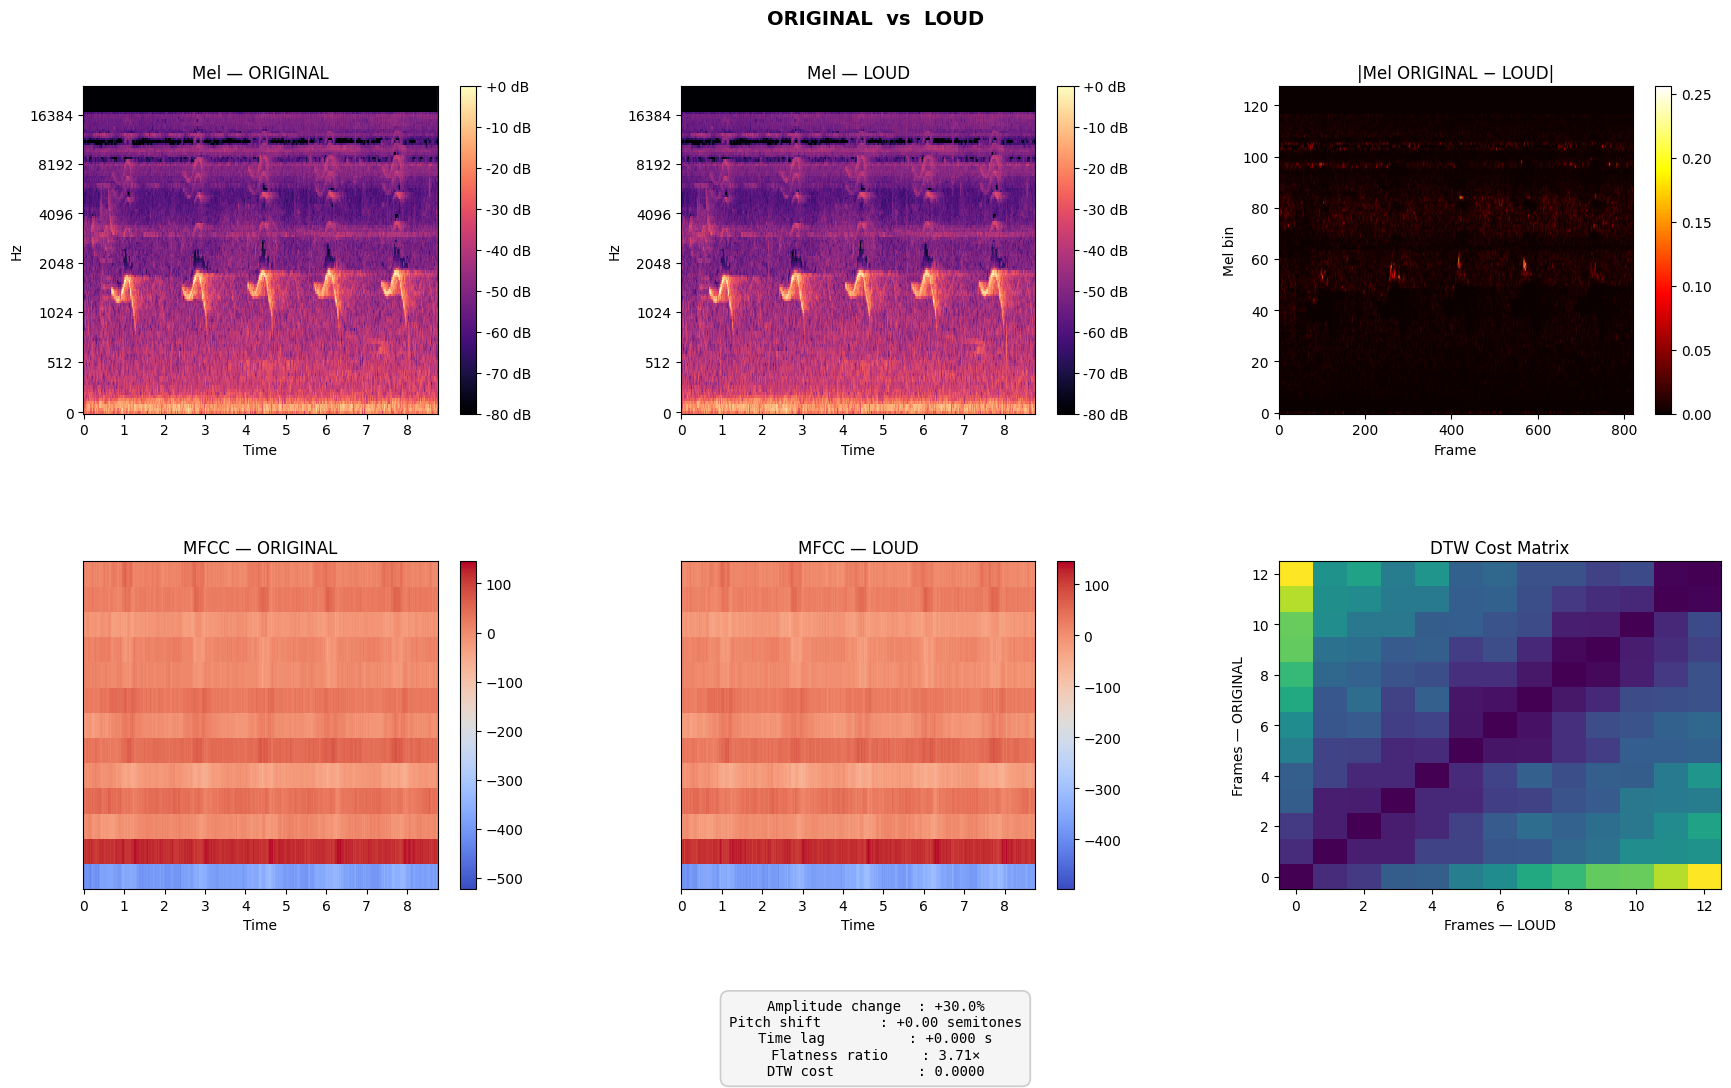

  Saved → spectrogram_outputs/comparisons/compare_ORIGINAL_vs_LOUD.png


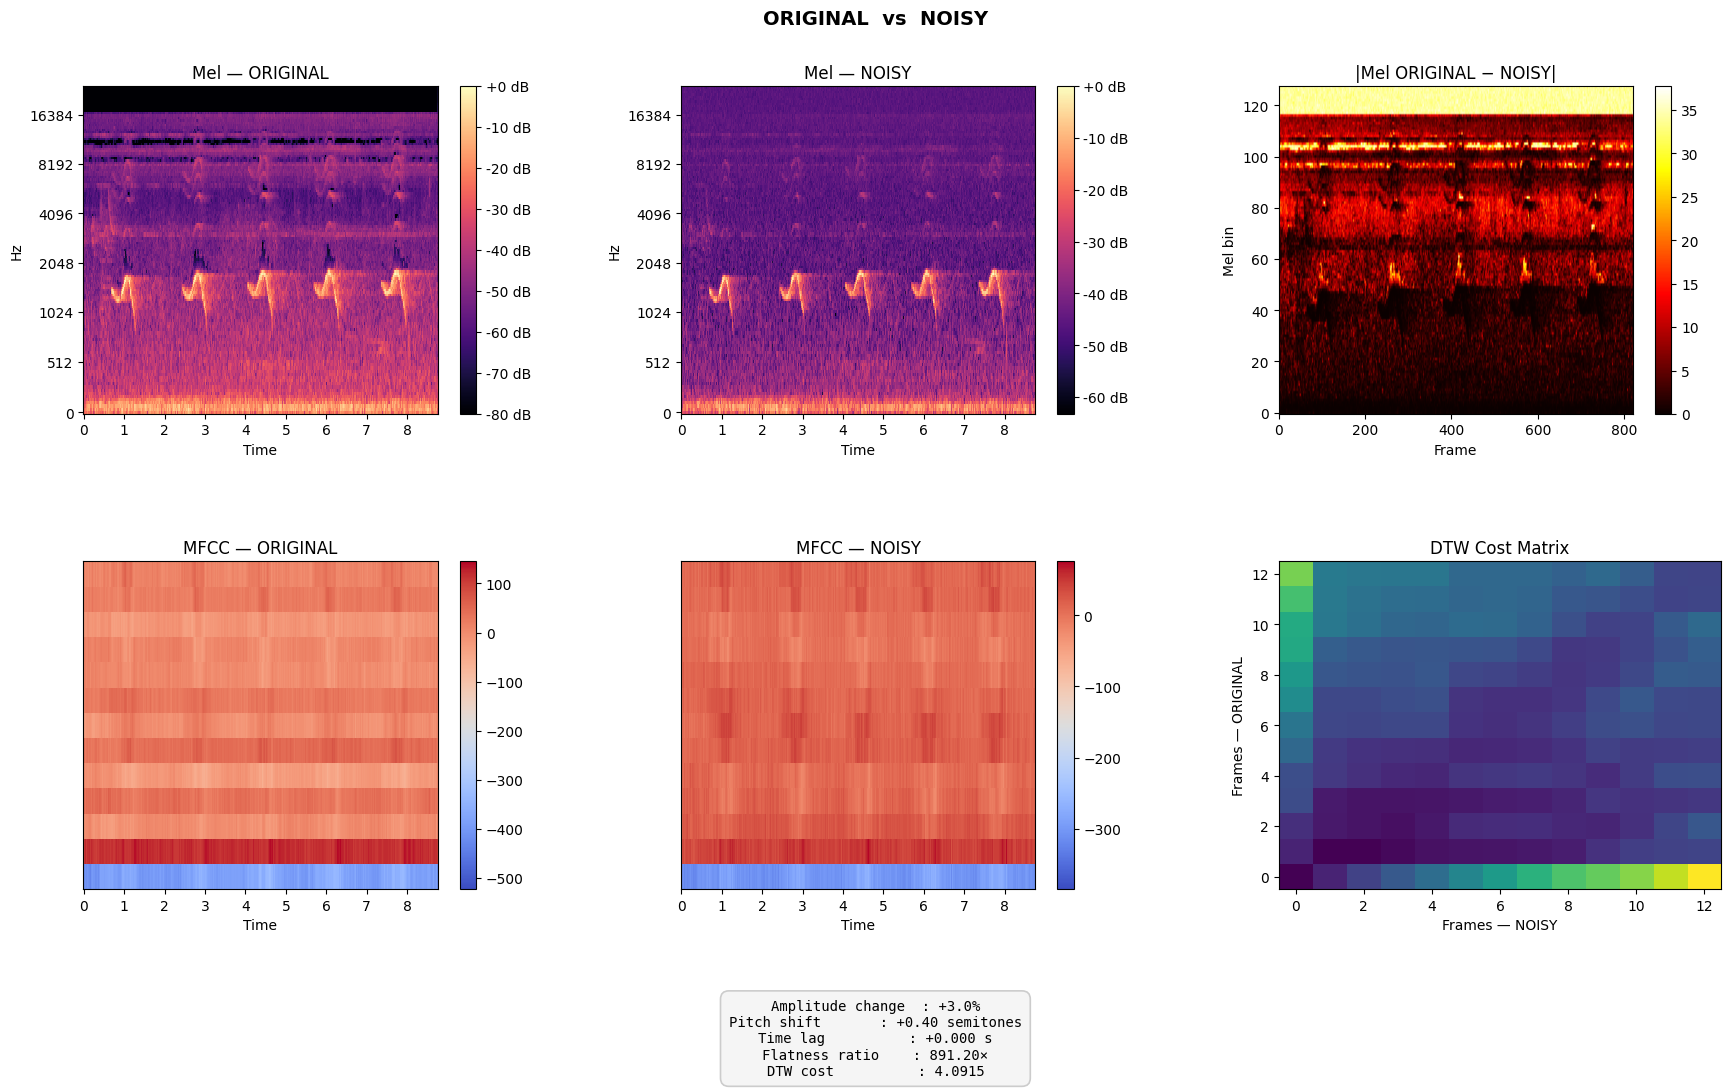

  Saved → spectrogram_outputs/comparisons/compare_ORIGINAL_vs_NOISY.png


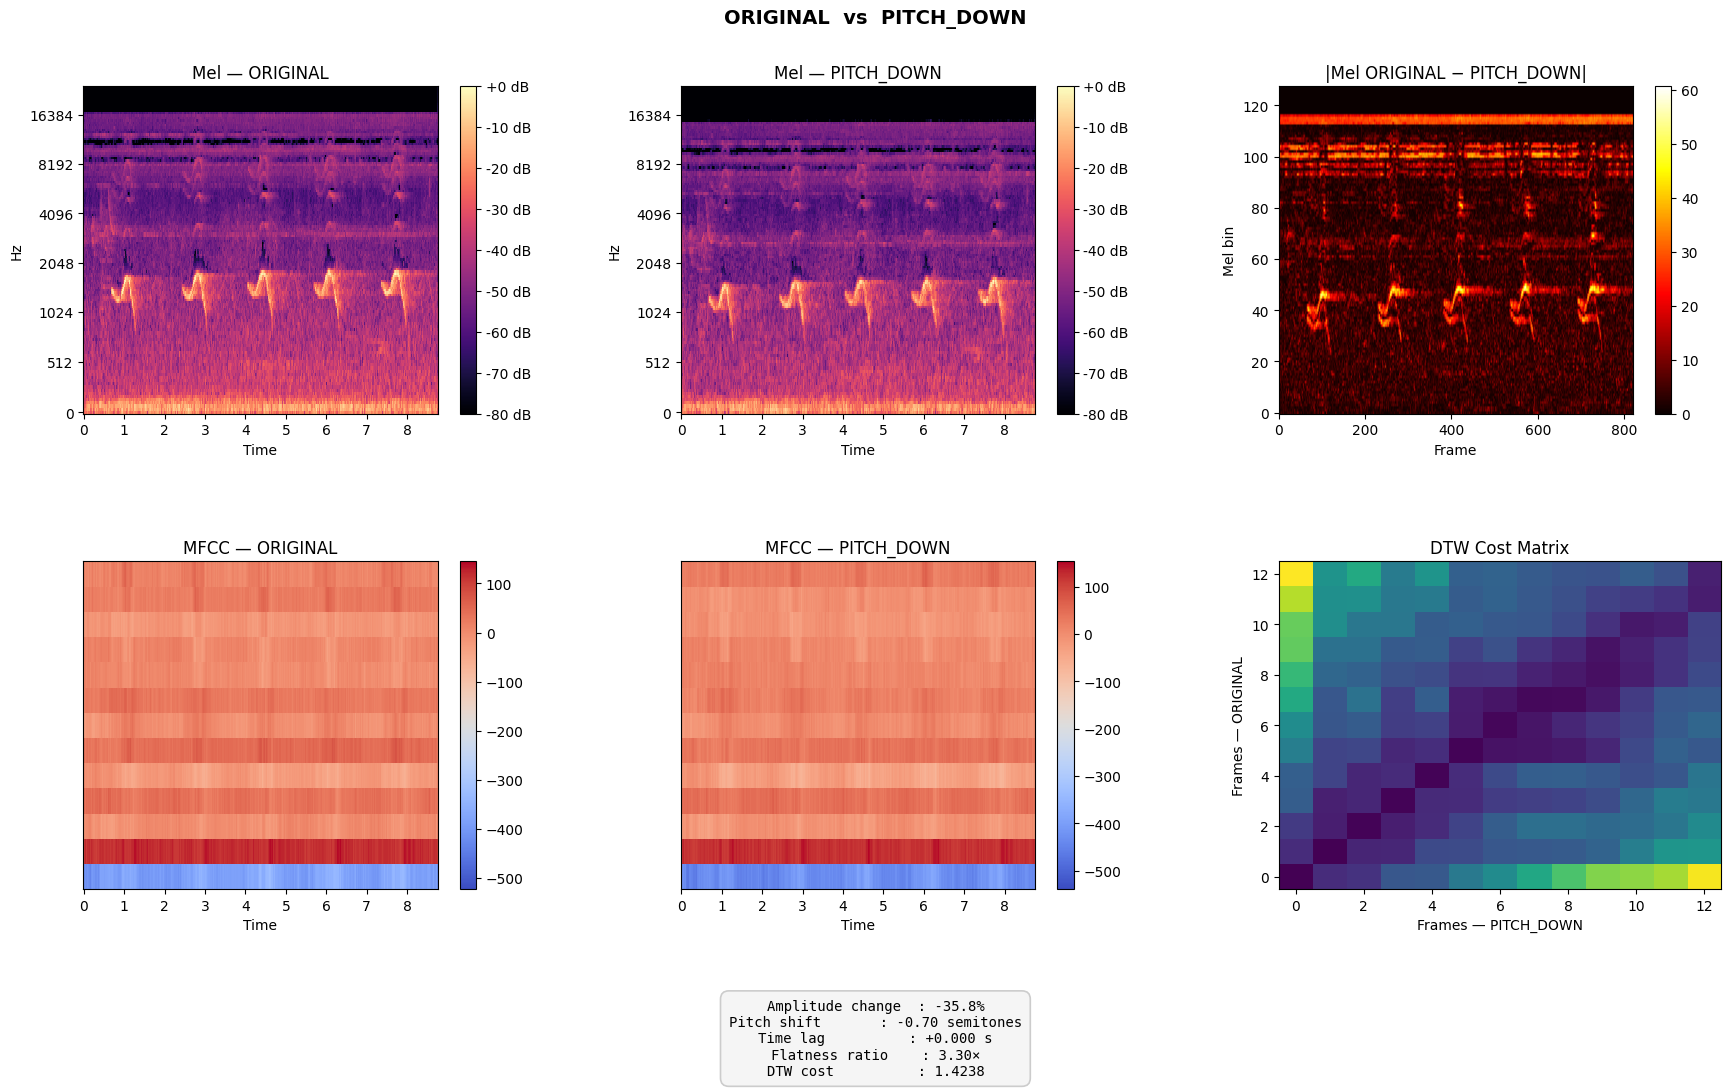

  Saved → spectrogram_outputs/comparisons/compare_ORIGINAL_vs_PITCH_DOWN.png


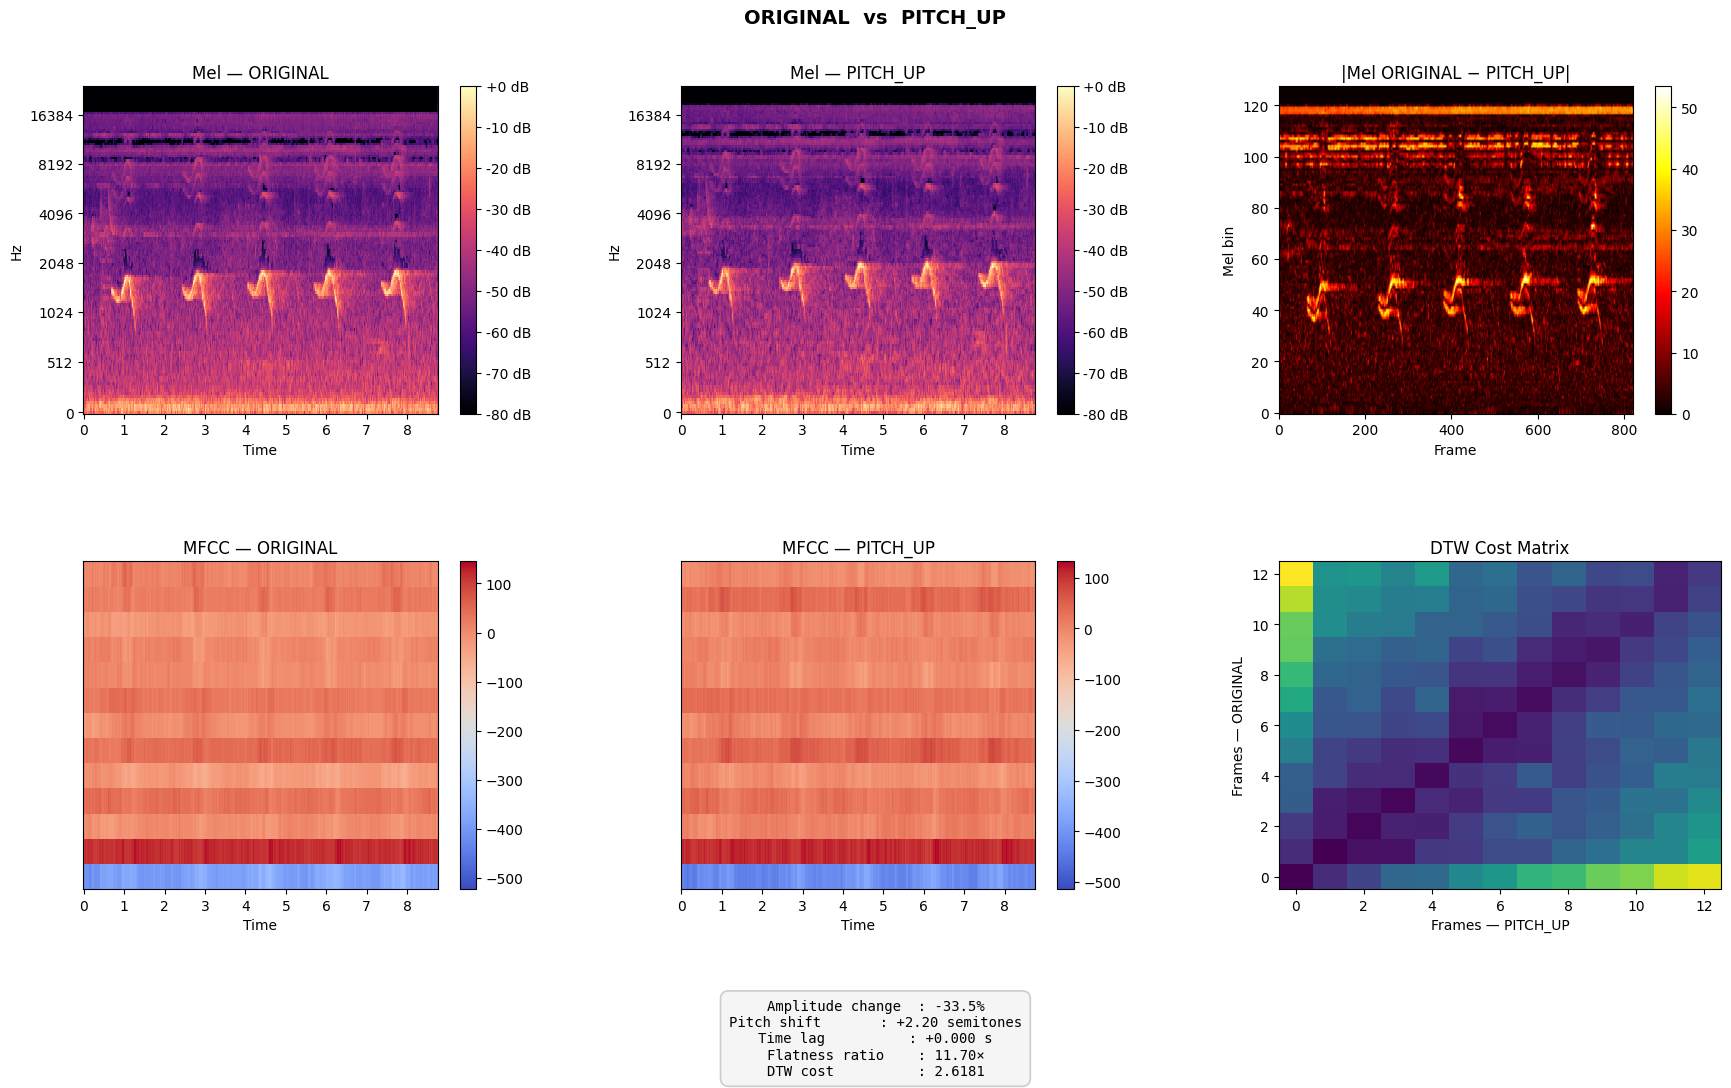

  Saved → spectrogram_outputs/comparisons/compare_ORIGINAL_vs_PITCH_UP.png


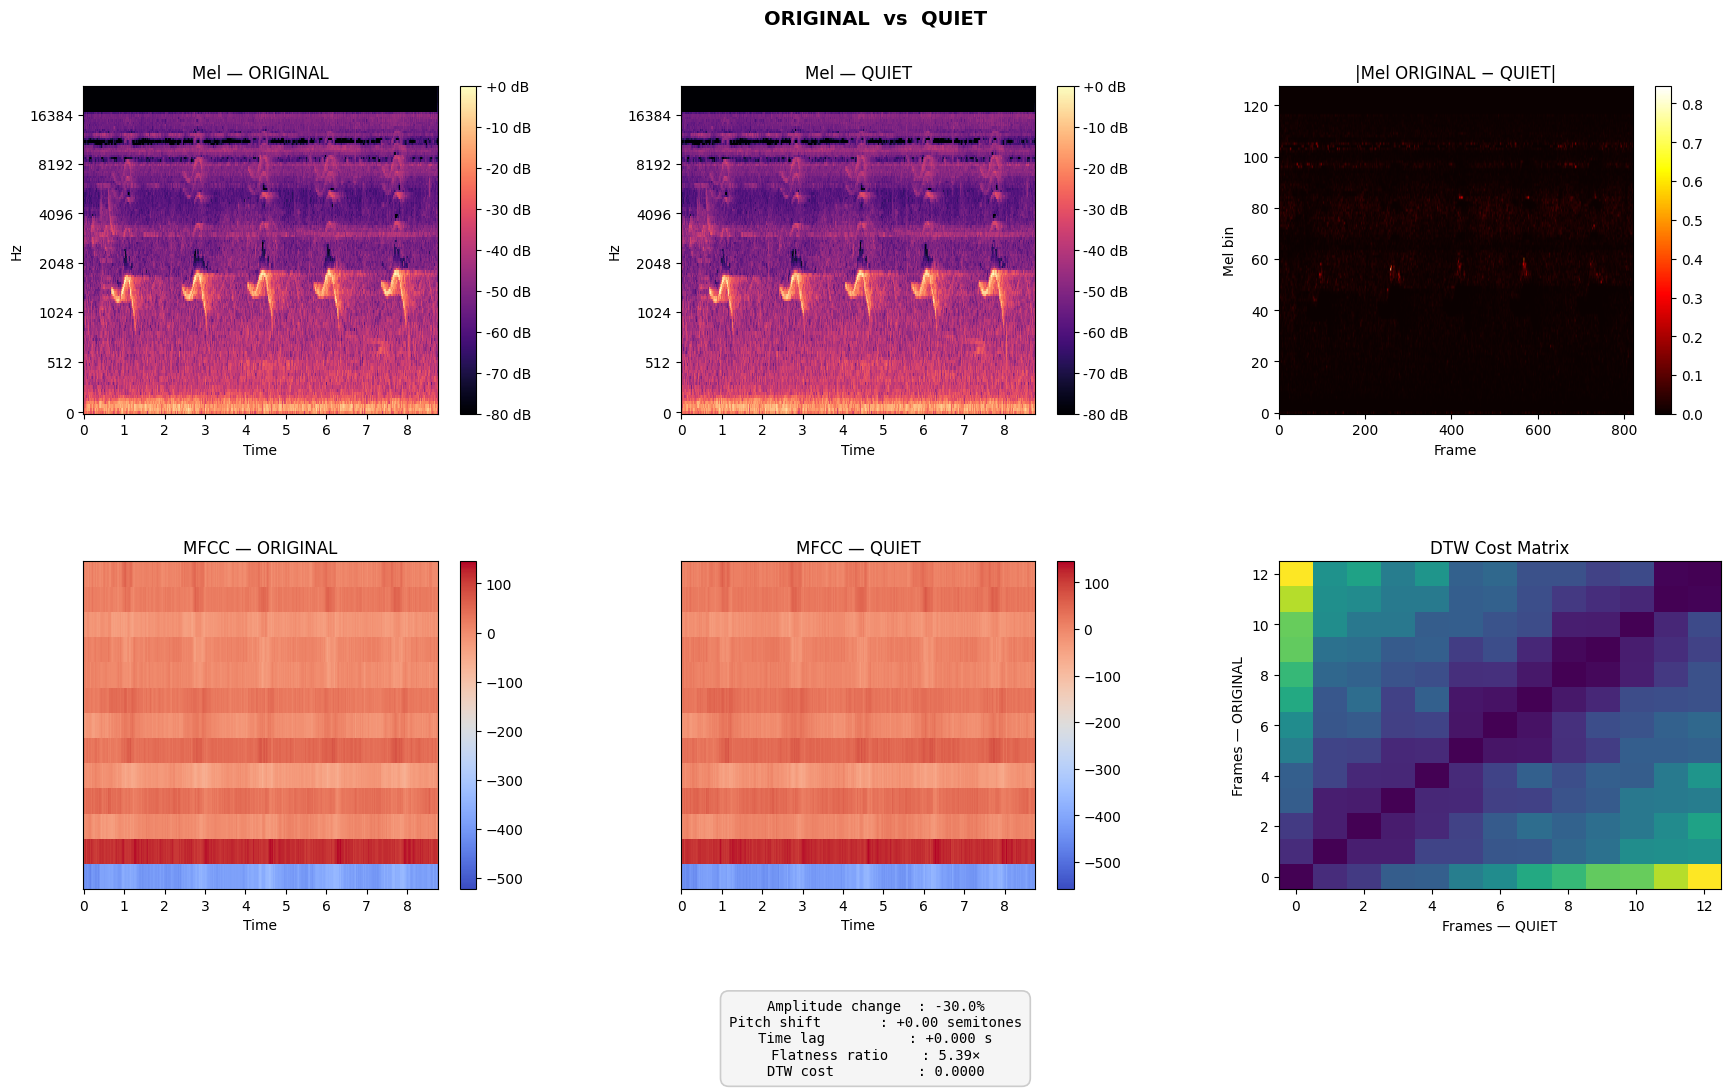

  Saved → spectrogram_outputs/comparisons/compare_ORIGINAL_vs_QUIET.png


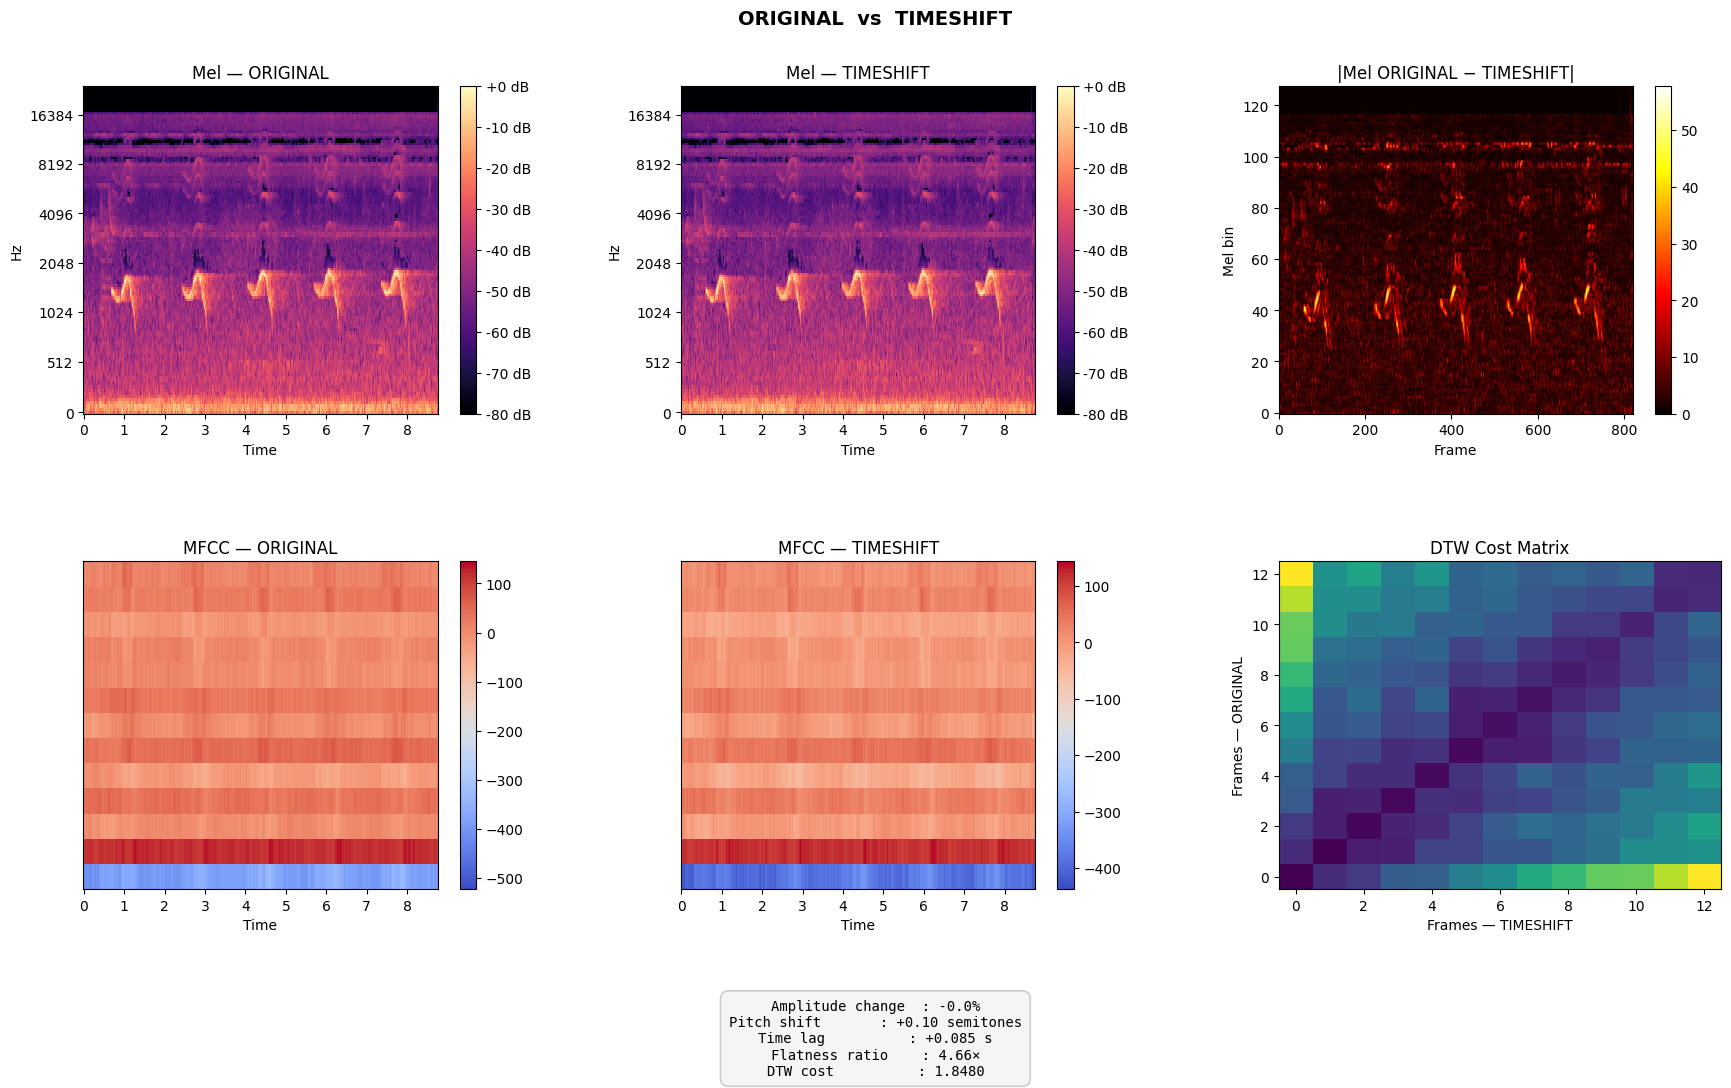

  Saved → spectrogram_outputs/comparisons/compare_ORIGINAL_vs_TIMESHIFT.png

All comparison images saved to: /content/drive/MyDrive/BirdNET_Singapore/data/augmented/spectrogram_outputs/comparisons


In [28]:
# ── Augmentation Comparison: Original vs Each Variant ───────
y_orig, sr = librosa.load(original, sr=None)

SAVE_DIR = DATA_DIR / 'spectrogram_outputs' / 'comparisons'
SAVE_DIR.mkdir(parents=True, exist_ok=True)

for path_b in selected_files:
    tag  = Path(path_b).stem.replace('Asian_Koel_XC1058398_', '').upper()
    yb, _ = librosa.load(path_b, sr=sr)

    # ── Compute features ─────────────────────────────────────
    mel_orig = librosa.power_to_db(librosa.feature.melspectrogram(y=y_orig, sr=sr), ref=np.max)
    mel_b    = librosa.power_to_db(librosa.feature.melspectrogram(y=yb,     sr=sr), ref=np.max)

    # Amplitude
    rms_orig = np.sqrt(np.mean(y_orig**2))
    rms_b    = np.sqrt(np.mean(yb**2))
    amp_change = (rms_b / rms_orig - 1.0) * 100

    # Pitch via pyin
    np.random.seed(42)
    f0_orig, vf_orig, _ = librosa.pyin(y_orig, fmin=100, fmax=8000, sr=sr, frame_length=2048)
    np.random.seed(42)
    f0_b,    vf_b,    _ = librosa.pyin(yb,     fmin=100, fmax=8000, sr=sr, frame_length=2048)
    voiced_orig = f0_orig[vf_orig & ~np.isnan(f0_orig)]
    voiced_b    = f0_b[vf_b       & ~np.isnan(f0_b)]
    semitones = 12 * np.log2(np.median(voiced_b) / np.median(voiced_orig)) \
                if len(voiced_orig) > 0 and len(voiced_b) > 0 else float('nan')

    # Time lag via onset envelope correlation
    env_orig   = librosa.onset.onset_strength(y=y_orig, sr=sr)
    env_b      = librosa.onset.onset_strength(y=yb,     sr=sr)
    n          = max(len(env_orig), len(env_b))
    corr       = np.correlate(
                     np.pad(env_orig, (0, n - len(env_orig))),
                     np.pad(env_b,    (0, n - len(env_b))),
                     mode='full')
    lag_seconds = (corr.argmax() - (n - 1)) * 512 / sr

    # Spectral flatness ratio
    flatness_orig = np.mean(librosa.feature.spectral_flatness(y=y_orig))
    flatness_b    = np.mean(librosa.feature.spectral_flatness(y=yb))
    flatness_ratio = flatness_b / flatness_orig

    # DTW cost
    mfcc_orig = librosa.feature.mfcc(y=y_orig, sr=sr, n_mfcc=13)
    mfcc_b    = librosa.feature.mfcc(y=yb,     sr=sr, n_mfcc=13)
    D, _      = librosa.sequence.dtw(mfcc_orig.T, mfcc_b.T, metric='cosine')
    dtw_cost  = D[-1, -1]

    # Mel diff
    T = max(mel_orig.shape[1], mel_b.shape[1])
    mel_orig_p = np.pad(mel_orig, ((0,0),(0, T - mel_orig.shape[1])))
    mel_b_p    = np.pad(mel_b,    ((0,0),(0, T - mel_b.shape[1])))
    mel_diff   = np.abs(mel_orig_p - mel_b_p)

    # ── Build summary text ───────────────────────────────────
    summary_lines = [
        f"Amplitude change  : {amp_change:+.1f}%",
        f"Pitch shift       : {semitones:+.2f} semitones" if not np.isnan(semitones) else "Pitch shift       : N/A",
        f"Time lag          : {lag_seconds:+.3f} s",
        f"Flatness ratio    : {flatness_ratio:.2f}×",
        f"DTW cost          : {dtw_cost:.4f}",
    ]
    summary_text = "\n".join(summary_lines)

    # ── Plot ─────────────────────────────────────────────────
    fig = plt.figure(figsize=(18, 11))
    fig.patch.set_facecolor('white')
    fig.suptitle(f"ORIGINAL  vs  {tag}", fontsize=14, fontweight='bold', y=0.98)

    gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35,
                           left=0.06, right=0.97, top=0.91, bottom=0.18)

    # Mel — Original
    ax1 = fig.add_subplot(gs[0, 0])
    img = librosa.display.specshow(mel_orig, sr=sr, x_axis='time', y_axis='mel', ax=ax1, cmap='magma')
    fig.colorbar(img, ax=ax1, format='%+2.0f dB')
    ax1.set_title('Mel — ORIGINAL')

    # Mel — Augmented
    ax2 = fig.add_subplot(gs[0, 1])
    img = librosa.display.specshow(mel_b, sr=sr, x_axis='time', y_axis='mel', ax=ax2, cmap='magma')
    fig.colorbar(img, ax=ax2, format='%+2.0f dB')
    ax2.set_title(f'Mel — {tag}')

    # Mel difference
    ax3 = fig.add_subplot(gs[0, 2])
    im = ax3.imshow(mel_diff, aspect='auto', origin='lower', cmap='hot')
    fig.colorbar(im, ax=ax3)
    ax3.set_title(f'|Mel ORIGINAL − {tag}|')
    ax3.set_xlabel('Frame')
    ax3.set_ylabel('Mel bin')

    # MFCC — Original
    ax4 = fig.add_subplot(gs[1, 0])
    img = librosa.display.specshow(mfcc_orig, sr=sr, x_axis='time', ax=ax4, cmap='coolwarm')
    fig.colorbar(img, ax=ax4)
    ax4.set_title('MFCC — ORIGINAL')

    # MFCC — Augmented
    ax5 = fig.add_subplot(gs[1, 1])
    img = librosa.display.specshow(mfcc_b, sr=sr, x_axis='time', ax=ax5, cmap='coolwarm')
    fig.colorbar(img, ax=ax5)
    ax5.set_title(f'MFCC — {tag}')

    # DTW cost matrix
    ax6 = fig.add_subplot(gs[1, 2])
    ax6.imshow(D, aspect='auto', origin='lower', cmap='viridis')
    ax6.set_title('DTW Cost Matrix')
    ax6.set_xlabel(f'Frames — {tag}')
    ax6.set_ylabel('Frames — ORIGINAL')

    # Summary text box below plots
    fig.text(
        0.5, 0.08, summary_text,
        ha='center', va='top',
        fontsize=10, fontfamily='monospace',
        bbox=dict(boxstyle='round,pad=0.6', facecolor='#f5f5f5',
                  edgecolor='#cccccc', linewidth=1.2)
    )

    save_path = SAVE_DIR / f"compare_ORIGINAL_vs_{tag}.png"
    plt.savefig(save_path, dpi=200, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"  Saved → {save_path.relative_to(DATA_DIR)}")

print(f"\nAll comparison images saved to: {SAVE_DIR}")